# Transfer Learning MNIST

* Train a simple convnet on the MNIST dataset the first 5 digits [0-4].
* Freeze convolutional layers and fine-tune dense layers for the classification of digits [5-9].

## MNIST Dataset
The MNIST database contains 60,000 training images and 10,000 testing images taken from American Census Bureau employees and American high school students. The MNIST dataset is one of the most common datasets used for image classification and accessible from many different sources. In fact, even Tensorflow and Keras allow us to import and download the MNIST dataset directly from their API.

In [2]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity='all'

In [3]:
import numpy as np
np.random.seed(42)

In [4]:
import  tensorflow as tf
tf.reset_default_graph()
tf.set_random_seed(42)

In [5]:
import keras
keras.__version__

Using TensorFlow backend.


'2.2.4'

In [6]:
tf.keras.__version__
tf.__version__

'2.2.4-tf'

'1.14.0'

Let's import keras and load MNIST dataset

In [7]:
# Initialize the random number generator
import random
random.seed(0)

import warnings
warnings.filterwarnings("ignore")

In [8]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

In [9]:
train_images.shape
train_labels.shape
test_images.shape
test_labels.shape
train_images.dtype
train_labels.dtype

(60000, 28, 28)

(60000,)

(10000, 28, 28)

(10000,)

dtype('uint8')

dtype('uint8')

X_train and X_test contain greyscale RGB codes (from 0 to 255) while y_train and y_test contains labels from 0 to 9 which represents which number they actually are.

Let's visualize some numbers using matplotlib

In [10]:
import matplotlib.pyplot as plt
%matplotlib inline

In [11]:
mnist_labels = [ "zero",  # index 0
                 "one",   # index 1
                 "two",   # index 2 
                 "three",   # index 3 
                 "four",    # index 4
                 "five",    # index 5
                 "six",     # index 6 
                 "seven",   # index 7 
                 "eight",   # index 8 
                 "nine"]   # index 9

In [12]:
def plot_images(image_label_tuple, grid_nums):
    plt.figure(figsize=(2*grid_nums, 2*grid_nums))
    for i in range(grid_nums**2):
        plt.subplot(grid_nums, grid_nums, i+1)
        plt.imshow(image_label_tuple[0][i], cmap='gray')
        plt.colorbar()
        plt.xticks([])
        plt.yticks([])
        plt.xlabel(mnist_labels[image_label_tuple[1][i]])
        plt.grid(False)
    plt.show()    

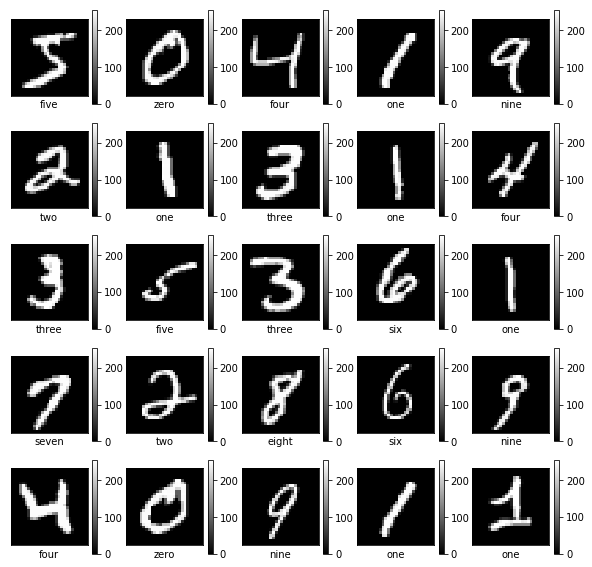

In [13]:
plot_images((train_images, train_labels),5)

## Question 1

### Create two datasets
- First having digits from 0 to 4
- Second having digits from 5 to 9

Hint: use labels to separate data

In [14]:
train_images_0_4 = np.array([train_images[i] for i, x in enumerate(train_labels.tolist()) if x < 5])
test_images_0_4 = np.array([test_images[i] for i, x in enumerate(test_labels.tolist()) if x < 5])
train_labels_0_4 = np.array([train_labels[i] for i, x in enumerate(train_labels.tolist()) if x < 5])
test_labels_0_4 = np.array([test_labels[i] for i, x in enumerate(test_labels.tolist()) if x < 5])

In [15]:
train_images_5_9 = np.array([train_images[i] for i, x in enumerate(train_labels.tolist()) if x >= 5])
test_images_5_9 = np.array([test_images[i] for i, x in enumerate(test_labels.tolist()) if x >= 5])
train_labels_5_9 = np.array([train_labels[i] for i, x in enumerate(train_labels.tolist()) if x >= 5])
test_labels_5_9 = np.array([test_labels[i] for i, x in enumerate(test_labels.tolist()) if x >= 5])

In [16]:
train_images_0_4.shape
test_images_0_4.shape

(30596, 28, 28)

(5139, 28, 28)

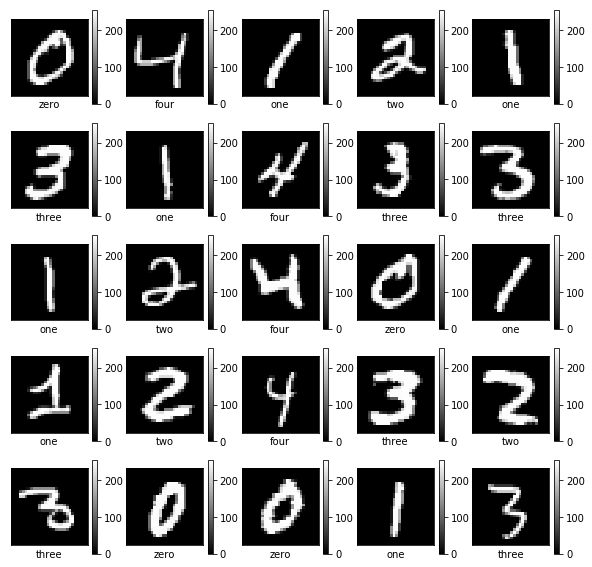

In [17]:
plot_images((train_images_0_4, train_labels_0_4),5)

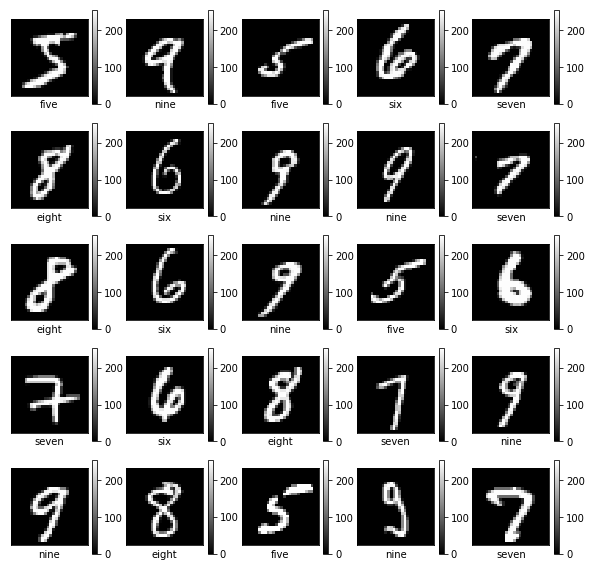

In [18]:
plot_images((train_images_5_9, train_labels_5_9),5)

## Question 2

### Print shape of the data
- print shape of all variables of both the datasets you created

In [19]:
train_images_0_4.shape
train_labels_0_4.shape
test_images_0_4.shape
test_labels_0_4.shape
train_images_5_9.shape
train_labels_5_9.shape
test_images_5_9.shape
test_labels_5_9.shape

(30596, 28, 28)

(30596,)

(5139, 28, 28)

(5139,)

(29404, 28, 28)

(29404,)

(4861, 28, 28)

(4861,)

### Using the reshape and Normalization as layer functions below for 3 & 4 below

In [20]:
tf.keras.backend.clear_session()
# Initialize model, reshape & normalize the data
model = tf.keras.models.Sequential()

## Question 3

### Reshape data
- reshape first dataset
- To be able to use the dataset in Keras, we need 4-dims numpy arrays. 
- reshape features to pass it to a Conv2D layer
- channel = 1
- reshape features of first dataset only
- do not reshape labels

In [21]:
# Reshape the data from 2D (28,28) to 3D(28,28, 1)
model.add(tf.keras.layers.Reshape(target_shape=(28,28,1), input_shape=(28,28)))

## Question 4

### Normalize data
- normalize first dataset
- we must normalize our data as it is always required in neural network models
- we can achieve this by dividing the RGB codes to 255 (which is the maximum RGB code minus the minimum RGB code)
- normalize X_train and X_test
- make sure that the values are float so that we can get decimal points after division

In [22]:
# Normalize the data
model.add(tf.keras.layers.BatchNormalization())

### Print shape of data and number of images
- for first dataset
- print shape of X_train
- print number of images in X_train
- print number of images in X_test

In [23]:
train_images_0_4.shape
train_labels_0_4.shape
test_images_0_4.shape
test_labels_0_4.shape

(30596, 28, 28)

(30596,)

(5139, 28, 28)

(5139,)

## Question 5

### One-hot encode the class vector
- encode labels of first dataset
- convert class vectors (integers) to binary class matrix
- convert y_train and y_test
- number of classes: 5
- we are doing this to use categorical_crossentropy as loss

Hint: you can use keras.utils.to_categorical

In [24]:
train_labels_0_4_one_hot = tf.keras.utils.to_categorical(train_labels_0_4)
test_labels_0_4_one_hot  = tf.keras.utils.to_categorical(test_labels_0_4)

In [25]:
train_labels_0_4_one_hot.shape
test_labels_0_4_one_hot.shape

(30596, 5)

(5139, 5)

## Question 6
We will build our model by using high level Keras.

### Initialize a sequential model
- define a sequential model
- add 2 convolutional layers
    - no of filters: 32
    - kernel size: 3x3
    - activation: "relu"
    - input shape: (28, 28, 1) for first layer
- add a max pooling layer of size 2x2
- add a dropout layer
    - dropout layers fight with the overfitting by disregarding some of the neurons while training
    - use dropout rate 0.2

In [26]:
# Add first convolutional layer
model.add(tf.keras.layers.Conv2D(32, # Num of convolutional feature-maps or num of filters
                                 kernel_size=(3,3), # Filter size
                                 activation='relu'))

# Add 2nd Convolutional layer
model.add(tf.keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))

# Add MaxPooling layer
model.add(tf.keras.layers.MaxPool2D(pool_size=(2,2)))

W0915 16:51:32.137998 20220 deprecation.py:506] From C:\Users\ojhaj\Anaconda3\lib\site-packages\tensorflow\python\ops\init_ops.py:1251: calling VarianceScaling.__init__ (from tensorflow.python.ops.init_ops) with dtype is deprecated and will be removed in a future version.
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


In [27]:
model.output

<tf.Tensor 'max_pooling2d/MaxPool:0' shape=(?, 12, 12, 64) dtype=float32>

## Question 7

### Add classification layers
- do this after doing question 6
- flatten the data
    - add Flatten later
    - flatten layers flatten 2D arrays to 1D array before building the fully connected layers
- add 2 dense layers
    - number of neurons in first layer: 128
    - number of neurons in last layer: number of classes
    - activation function in first layer: relu
    - activation function in last layer: softmax
    - we may experiment with any number of neurons for the first Dense layer; however, the final Dense layer must have neurons equal to the number of output classes
- you can add a dropout layer in between, if necessary

In [28]:
# Flatten the output
model.add(tf.keras.layers.Flatten())

# Add first Dense layer
model.add(tf.keras.layers.Dense(128, activation='relu'))

# Add Droput layer
model.add(tf.keras.layers.Dropout(rate=0.2))

# Add output layer
model.add(tf.keras.layers.Dense(5, activation='softmax', kernel_regularizer=tf.keras.regularizers.l2(0.01)))

## Question 8

### Compile and fit the model
- compile your model
    - loss: "categorical_crossentropy"
    - metrics: "accuracy"
    - optimizer: "sgd"
- fit your model
    - give train data - features and labels
    - batch size: 128
    - epochs: 10
    - give validation data - features and labels

In [29]:
model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

In [30]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
reshape (Reshape)            (None, 28, 28, 1)         0         
_________________________________________________________________
batch_normalization (BatchNo (None, 28, 28, 1)         4         
_________________________________________________________________
conv2d (Conv2D)              (None, 26, 26, 32)        320       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 24, 24, 64)        18496     
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 12, 12, 64)        0         
_________________________________________________________________
flatten (Flatten)            (None, 9216)              0         
_________________________________________________________________
dense (Dense)                (None, 128)               1

In [31]:
model.fit(train_images_0_4, train_labels_0_4_one_hot, batch_size=128, validation_data=(test_images_0_4, test_labels_0_4_one_hot), shuffle=True, epochs=10)

Train on 30596 samples, validate on 5139 samples
Epoch 1/10
30596/30596 [==============================] - 5s 156us/sample - loss: 0.3379 - acc: 0.9317 - val_loss: 1.4221 - val_acc: 0.6410
Epoch 2/10
30596/30596 [==============================] - 3s 109us/sample - loss: 0.1910 - acc: 0.9682 - val_loss: 0.1342 - val_acc: 0.9854
Epoch 3/10
30596/30596 [==============================] - 3s 109us/sample - loss: 0.1564 - acc: 0.9762 - val_loss: 0.1243 - val_acc: 0.9860
Epoch 4/10
30596/30596 [==============================] - 3s 110us/sample - loss: 0.1367 - acc: 0.9805 - val_loss: 0.1089 - val_acc: 0.9889
Epoch 5/10
30596/30596 [==============================] - 3s 110us/sample - loss: 0.1216 - acc: 0.9834 - val_loss: 0.0961 - val_acc: 0.9907
Epoch 6/10
30596/30596 [==============================] - 3s 112us/sample - loss: 0.1125 - acc: 0.9841 - val_loss: 0.0898 - val_acc: 0.9916
Epoch 7/10
30596/30596 [==============================] - 3s 109us/sample - loss: 0.1019 - acc: 0.9860 - val_lo

## Question 9

### Evaluate model
- evaluate your model and get accuracy
- use test features and labels

In [32]:
score = model.evaluate(test_images_0_4, test_labels_0_4_one_hot)
score[1]

5139/5139 [==============================] - 0s 89us/sample - loss: 0.0645 - acc: 0.9932


0.99318933

In [33]:
model.save('mnist_0_4.h5')

In [34]:
train_labels_5_9.shape

(29404,)

In [35]:
np.unique(train_labels_5_9)

array([5, 6, 7, 8, 9], dtype=uint8)

In [36]:
train_labels_5_9_one_hot = tf.keras.utils.to_categorical(train_labels_5_9-5, num_classes=5)
test_labels_5_9_one_hot  = tf.keras.utils.to_categorical(test_labels_5_9-5, num_classes=5)

In [37]:
train_labels_5_9

array([5, 9, 5, ..., 5, 6, 8], dtype=uint8)

In [38]:
np.unique(train_labels_5_9)

array([5, 6, 7, 8, 9], dtype=uint8)

In [39]:
train_labels_5_9_one_hot.shape

(29404, 5)

## Question 10

## Transfer learning
Now we will apply this model on second dataset (5-9 digits)

- fix the first convolution layers so that the weights in the convolution layers dont get updated in the process of training
- get the second dataset
- train the last 2 dense layers
- predict the accuracy and loss

In [40]:
def layer_output(model, layer_name=None):
    """Output tensor of a specific layer in a model.
    """
    conv_index = -1

    for i in range(len(model.layers) - 1, -1, -1):
        layer = model.layers[i]
        if layer_name in layer.name:
            conv_index = i
            break

    if conv_index < 0:
        print('Error: could not find the interested layer.')

    return model.layers[conv_index].output

In [41]:
baseModel = tf.keras.models.load_model('mnist_0_4.h5')

# show a summary of the base model
print("[INFO] summary for base model...")
print(baseModel.summary())

new_input = layer_output(baseModel, 'max_pooling2d')
new_input
# construct the head of the model that will be placed on top of the
# the base model
headModel = new_input
# Flatten the output
headModel = tf.keras.layers.Flatten()(headModel)

headModel = tf.keras.layers.Dense(128, activation='relu')(headModel)
headModel = tf.keras.layers.Dropout(0.2)(headModel)
headModel = tf.keras.layers.Dense(5, activation='softmax', kernel_regularizer=tf.keras.regularizers.l2(0.01))(headModel)

# place the head FC model on top of the base model (this will become
# the actual model we will train)
model_new = tf.keras.models.Model(inputs=baseModel.input, outputs=headModel)

# loop over all layers in the base model and freeze them so they will
# *not* be updated during the first training process
for layer in baseModel.layers:
    layer.trainable = False

# compile our model (this needs to be done after our setting our
# layers to being non-trainable)
print("[INFO] compiling model...")
opt = tf.keras.optimizers.SGD(lr=1e-4)
model_new.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
# summarize layers
print(model_new.summary())


W0915 16:52:34.309322 20220 deprecation.py:506] From C:\Users\ojhaj\Anaconda3\lib\site-packages\tensorflow\python\ops\init_ops.py:97: calling Zeros.__init__ (from tensorflow.python.ops.init_ops) with dtype is deprecated and will be removed in a future version.
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
W0915 16:52:34.310345 20220 deprecation.py:506] From C:\Users\ojhaj\Anaconda3\lib\site-packages\tensorflow\python\ops\init_ops.py:97: calling Ones.__init__ (from tensorflow.python.ops.init_ops) with dtype is deprecated and will be removed in a future version.
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
W0915 16:52:34.349792 20220 deprecation.py:506] From C:\Users\ojhaj\Anaconda3\lib\site-packages\tensorflow\python\ops\init_ops.py:97: calling GlorotUniform.__init__ (from tensorflow.python.ops.init_ops) with dtype is deprecated and will be rem

[INFO] summary for base model...
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
reshape (Reshape)            (None, 28, 28, 1)         0         
_________________________________________________________________
batch_normalization (BatchNo (None, 28, 28, 1)         4         
_________________________________________________________________
conv2d (Conv2D)              (None, 26, 26, 32)        320       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 24, 24, 64)        18496     
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 12, 12, 64)        0         
_________________________________________________________________
flatten (Flatten)            (None, 9216)              0         
_________________________________________________________________
dense (Dense)          

<tf.Tensor 'max_pooling2d_1/MaxPool:0' shape=(?, 12, 12, 64) dtype=float32>

[INFO] compiling model...
Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
reshape_input (InputLayer)   [(None, 28, 28)]          0         
_________________________________________________________________
reshape (Reshape)            (None, 28, 28, 1)         0         
_________________________________________________________________
batch_normalization (BatchNo (None, 28, 28, 1)         4         
_________________________________________________________________
conv2d (Conv2D)              (None, 26, 26, 32)        320       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 24, 24, 64)        18496     
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 12, 12, 64)        0         
_________________________________________________________________
flatten_1 (Flatten)          (None,

In [43]:
model_new.fit(train_images_5_9, train_labels_5_9_one_hot, batch_size=128, validation_data=(test_images_5_9, test_labels_5_9_one_hot), shuffle=True, epochs=20)

Train on 29404 samples, validate on 4861 samples
Epoch 1/20
29404/29404 [==============================] - 2s 56us/sample - loss: 0.3052 - acc: 0.9341 - val_loss: 0.2662 - val_acc: 0.9480
Epoch 2/20
29404/29404 [==============================] - 2s 56us/sample - loss: 0.2990 - acc: 0.9351 - val_loss: 0.2619 - val_acc: 0.9486
Epoch 3/20
29404/29404 [==============================] - 2s 56us/sample - loss: 0.2938 - acc: 0.9375 - val_loss: 0.2571 - val_acc: 0.9510
Epoch 4/20
29404/29404 [==============================] - 2s 56us/sample - loss: 0.2857 - acc: 0.9395 - val_loss: 0.2535 - val_acc: 0.9519
Epoch 5/20
29404/29404 [==============================] - 2s 56us/sample - loss: 0.2813 - acc: 0.9426 - val_loss: 0.2492 - val_acc: 0.9527
Epoch 6/20
29404/29404 [==============================] - 2s 56us/sample - loss: 0.2792 - acc: 0.9423 - val_loss: 0.2460 - val_acc: 0.9549
Epoch 7/20
29404/29404 [==============================] - 2s 55us/sample - loss: 0.2745 - acc: 0.9441 - val_loss: 0.2

### Make only dense layers trainable
- set trainalble = False for all layers other than Dense layers

*** The above cell has the required lines: 

### Modify data
- in your second data, class labels will start from 5 to 9 but for keras.utils.to_categorical the labels should start from 0
- so you need to subtract 5 from train and test labels

*** The above cell has the required lines: 

### Reshape data
- reshape second dataset
- To be able to use the dataset in Keras, we need 4-dims numpy arrays. 
- reshape features to pass it to a Conv2D layer
- channel = 1
- reshape features of first dataset only
- do not reshape labels

*** the pretrained model includes both reshaping and normalization

### Normalize data
- normalize second data
- we must normalize our data as it is always required in neural network models
- we can achieve this by dividing the RGB codes to 255 (which is the maximum RGB code minus the minimum RGB code)
- normalize X_train and X_test
- make sure that the values are float so that we can get decimal points after division

*** the pretrained model includes both reshaping and normalization

### Print shape of data and number of images
- print shape of X_train
- print number of images in X_train
- print number of images in X_test

*** one of the cell has the required lines: 

### One-hot encode the class vector
- convert class vectors (integers) to binary class matrix
- convert y_train and y_test
- number of classes: 5
- we are doing this to use categorical_crossentropy as loss

Hint: you can use keras.utils.to_categorical

*** one of the cell above has the required lines: 

### Fit the model
- give train data - features and labels
- batch size: 128
- epochs: 10
- give validation data - features and labels

*** one of the cell above has the required lines: 

### Evaluate model
- evaluate your model and get accuracy
- use test features and labels

In [44]:
score = model_new.evaluate(test_images_5_9, test_labels_5_9_one_hot)
score[1]

4861/4861 [==============================] - 0s 94us/sample - loss: 0.2175 - acc: 0.9615


0.96153057

-----------------------------------------------------------------------------

# Sentiment analysis 

The objective of the second problem is to perform Sentiment analysis from the tweets collected from the users targeted at various mobile devices.
Based on the tweet posted by a user (text), we will classify if the sentiment of the user targeted at a particular mobile device is positive or not.

## Question 1

### Read the data
- read tweets.csv
- use latin encoding if it gives encoding error while loading

In [81]:
import pandas as pd
import spacy
import nltk
from nltk.tokenize.toktok import ToktokTokenizer
import re
import unicodedata

In [82]:
tweet_df = pd.read_csv('./tweets.csv', encoding="ISO-8859-1")

In [83]:
tweet_df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


### Drop null values
- drop all the rows with null values

In [84]:
tweet_df.dropna(inplace=True)

### Print the dataframe
- print initial 5 rows of the data
- use df.head()

In [85]:
tweet_df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


## Question 2

### Preprocess data
- convert all text to lowercase - use .lower()
- select only numbers, alphabets, and #+_ from text - use re.sub()
- strip all the text - use .strip()
    - this is for removing extra spaces

In [86]:
tweet_df['tweet_text'] = tweet_df['tweet_text'].str.lower()
def convert_tweets(row):
  message = row['tweet_text']
  tokens = nltk.word_tokenize(message)
  # taken only words (not punctuation)
  token_words = [w for w in tokens if w.isalpha() or w.isnumeric()]
  s =  " "
  joined_words = (s.join(token_words))
  return joined_words
tweet_df['tweet_text'] = tweet_df.apply(convert_tweets, axis=1)

print dataframe

In [87]:
tweet_df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,i have a iphone after 3 hrs tweeting at it was...,iPhone,Negative emotion
1,jessedee know about fludapp awesome app that y...,iPad or iPhone App,Positive emotion
2,swonderlin can not wait for ipad 2 also they s...,iPad,Positive emotion
3,sxsw i hope this year festival is as crashy as...,iPad or iPhone App,Negative emotion
4,sxtxstate great stuff on fri sxsw marissa maye...,Google,Positive emotion


## Question 3

### Preprocess data
- in column "is_there_an_emotion_directed_at_a_brand_or_product"
    - select only those rows where value equal to "positive emotion" or "negative emotion"
- find the value counts of "positive emotion" and "negative emotion"

In [88]:
tweet_df = tweet_df.apply(lambda x: x.astype(str).str.lower())
tweet_df.head()


,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,i have a iphone after 3 hrs tweeting at it was...,iphone,negative emotion
1,jessedee know about fludapp awesome app that y...,ipad or iphone app,positive emotion
2,swonderlin can not wait for ipad 2 also they s...,ipad,positive emotion
3,sxsw i hope this year festival is as crashy as...,ipad or iphone app,negative emotion
4,sxtxstate great stuff on fri sxsw marissa maye...,google,positive emotion


In [89]:
tweet_df.columns

Index(['tweet_text', 'emotion_in_tweet_is_directed_at',
       'is_there_an_emotion_directed_at_a_brand_or_product'],
      dtype='object')

In [90]:
tweet_df = tweet_df[(tweet_df.is_there_an_emotion_directed_at_a_brand_or_product == 'positive emotion') | 
                     (tweet_df.is_there_an_emotion_directed_at_a_brand_or_product == 'negative emotion')] 

tweet_df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,i have a iphone after 3 hrs tweeting at it was...,iphone,negative emotion
1,jessedee know about fludapp awesome app that y...,ipad or iphone app,positive emotion
2,swonderlin can not wait for ipad 2 also they s...,ipad,positive emotion
3,sxsw i hope this year festival is as crashy as...,ipad or iphone app,negative emotion
4,sxtxstate great stuff on fri sxsw marissa maye...,google,positive emotion


In [91]:
tweet_df['is_there_an_emotion_directed_at_a_brand_or_product'].value_counts()

positive emotion    2672
negative emotion     519
Name: is_there_an_emotion_directed_at_a_brand_or_product, dtype: int64

## Question 4

### Encode labels
- in column "is_there_an_emotion_directed_at_a_brand_or_product"
    - change "positive emotion" to 1
    - change "negative emotion" to 0
- use map function to replace values

In [92]:
# convert label to a numerical variable
tweet_df['is_there_an_emotion_directed_at_a_brand_or_product'] = tweet_df.is_there_an_emotion_directed_at_a_brand_or_product.map({'positive emotion':1, 'negative emotion':0})
tweet_df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,i have a iphone after 3 hrs tweeting at it was...,iphone,0
1,jessedee know about fludapp awesome app that y...,ipad or iphone app,1
2,swonderlin can not wait for ipad 2 also they s...,ipad,1
3,sxsw i hope this year festival is as crashy as...,ipad or iphone app,0
4,sxtxstate great stuff on fri sxsw marissa maye...,google,1


In [93]:
tweet_df['is_there_an_emotion_directed_at_a_brand_or_product'].value_counts()

1    2672
0     519
Name: is_there_an_emotion_directed_at_a_brand_or_product, dtype: int64

## Question 5

### Get feature and label
- get column "tweet_text" as feature
- get column "is_there_an_emotion_directed_at_a_brand_or_product" as label

In [94]:
X = tweet_df.tweet_text
y = tweet_df.is_there_an_emotion_directed_at_a_brand_or_product
print(X.shape)
print(y.shape)

(3191,)
(3191,)


In [95]:
tweet_df.dtypes

tweet_text                                            object
emotion_in_tweet_is_directed_at                       object
is_there_an_emotion_directed_at_a_brand_or_product     int64
dtype: object

### Create train and test data
- use train_test_split to get train and test set
- set a random_state
- test_size: 0.25

In [96]:
# split X and y into training and testing sets 
#use sklearn.model_selection 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25, random_state=2)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2393,)
(798,)
(2393,)
(798,)


## Question 6

### Vectorize data
- create document-term matrix
- use CountVectorizer()
    - ngram_range: (1, 2)
    - stop_words: 'english'
    - min_df: 2   
- do fit_transform on X_train
- do transform on X_test

In [99]:
from sklearn.feature_extraction.text import CountVectorizer
# include 1-grams and 2-grams
vect = CountVectorizer(ngram_range=(1, 2),stop_words='english',min_df=2,max_df=.5)

## Question 7

### Select classifier logistic regression
- use logistic regression for predicting sentiment of the given tweet
- initialize classifier

In [100]:
X_train_dtm = vect.fit_transform(X_train)

In [101]:
# transform testing data (using fitted vocabulary) into a document-term matrix
X_test_dtm = vect.transform(X_test)
X_test_dtm

<798x5259 sparse matrix of type '<class 'numpy.int64'>'
	with 9384 stored elements in Compressed Sparse Row format>

### Fit the classifer
- fit logistic regression classifier

In [103]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
# train the model using X_train_dtm
logreg.fit(X_train_dtm, y_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='warn',
          n_jobs=None, penalty='l2', random_state=None, solver='warn',
          tol=0.0001, verbose=0, warm_start=False)

## Question 8

### Select classifier naive bayes
- use naive bayes for predicting sentiment of the given tweet
- initialize classifier
- use MultinomialNB

In [104]:
# import and instantiate a Multinomial Naive Bayes model
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()

### Fit the classifer
- fit naive bayes classifier

In [105]:
# train the model using X_train_dtm
nb.fit(X_train_dtm, y_train)

MultinomialNB(alpha=1.0, class_prior=None, fit_prior=True)

## Question 9

### Make predictions on logistic regression
- use your trained logistic regression model to make predictions on X_test

In [106]:
# make class predictions for X_test_dtm
y_pred_class = logreg.predict(X_test_dtm)

### Make predictions on naive bayes
- use your trained naive bayes model to make predictions on X_test
- use a different variable name to store predictions so that they are kept separately

In [107]:
y_pred = nb.predict(X_test_dtm)

## Question 10

### Calculate accuracy of logistic regression
- check accuracy of logistic regression classifer
- use sklearn.metrics.accuracy_score

In [108]:
from sklearn import metrics
print('Logistic Regression Accuracy:',metrics.accuracy_score(y_test, y_pred_class))

Logistic Regression Accuracy: 0.868421052631579


### Calculate accuracy of naive bayes
- check accuracy of naive bayes classifer
- use sklearn.metrics.accuracy_score

In [109]:
print('Naive Base Accuracy:',metrics.accuracy_score(y_test, y_pred))

Naive Base Accuracy: 0.8558897243107769
